# Deep Momentum — Canada (Norgate)

End-to-end pipeline: load → aggregate → filter → features → walk-forward XGBoost → paper-style diagnostics → canonical daily backtest.

**Universe**: Canadian equity market from Norgate, listed and delisted, with survivorship-bias-safe daily data.

**Adjustable params at the top of the notebook** — change these to sweep configurations without touching the worker modules.


## 0. Master parameters
Everything tunable lives here.


In [1]:
pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 76.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 120.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 236.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.8/48.8 MB 146.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 102.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 81.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.9/16.9 MB 172.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.3/21.3 MB 77.8 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 145.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 103.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 215.6 MB/s eta 0:00:00
  Attempting uninstall: pyparsing
    Found existing installation: pyparsing 2.4.7
    Uninstalling pyp

In [2]:
import warnings
warnings.filterwarnings('ignore')

# ── Filtering ───────────────────────────────────────────────────────
USE_LEGACY_LIQ_FILTER = False  # old turnover-ratio filter; keep off when using tradability filter
OPERATING_ONLY   = True    # only is_operating_company == True (Norgate classification)
EXCHANGES        = ['TSX'] # senior exchange only — paper-closest universe (~6,227 stocks ever, ~2,000 active/mo)
                            #   None for full 10,652-stock universe; ['TSX', 'TSX Venture'] for broader (~8,537)
USE_PIT_INDEX    = None               # point-in-time index universe filter — subsumes liquidity + operating-only
                                       # options: 'sptsx_composite' | 'sptsx_60' | 's_p_tsx_smallcap' | None to disable


# -- Tradability universe (applied before features/model) --------------------
USE_TRADABILITY_FILTER      = True
MIN_PRICE_CAD              = 5.0      # try 5.0 and 10.0 as primary robustness cases
TURNOVER_BOTTOM_PCT        = 0.20         # drop bottom 20% by monthly median daily turnover
REQUIRE_FULL_MONTH_TRADING = True
MAX_ZERO_VOLUME_SHARE      = 0.00         # full-month trading usually makes this redundant
REBUILD_PREDICTIONS        = True     # feature set changed; retrain instead of using stale cached preds

# ── Walk-forward training ───────────────────────────────────────────
N_ENSEMBLE       = 100     # XGBoost models trained per retraining date (paper uses 100)

# ── Portfolio (top-N, baseline EW) ──────────────────────────────────
TOP_N              = 15    # int > 1 → fixed N per leg; 0<float≤1 → percentile of cross-section
                            #   0.10 = paper's decile cut (~25 names per leg on TSX Composite)
TC_BPS             = 20.0  # one-way commission, bps of notional
CARRY_LONG_ANNUAL  = 0.05  # long financing rate (cost)
CARRY_SHORT_ANNUAL = 0.02  # short financing rate (earned; 0 for Saxo, ~2% for IBKR)
DAYS_PER_MONTH     = 30    # calendar days for monthly financing pro-rate
LONG_ONLY          = True # True = drop short leg entirely (diagnostic; avoids compounding blow-ups when shorts surge)

# ── Plotting palette (Dark2-style; matches finance-data-science repo) ──
PALETTE = {
    'primary':   '#1b9e77',
    'secondary': '#7570b3',
    'tertiary':  '#d95f02',
    'accent':    '#e7298a',
    'neutral':   '#666666',
    'bg':        '#f7f7f7',
}
import matplotlib.pyplot as plt
plt.rcParams.update({
    'figure.figsize':    (10, 5),
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'grid.linestyle':    '--',
    'font.size':         10,
    'legend.frameon':    False,
})


## 1. Load Norgate exports → daily parquet
Reads ~14k CA equity CSVs (listed + delisted) and the CADUSD spot series.


In [3]:
from data_load import load_norgate_equities, load_cadusd, CACHE_DIR
from pathlib import Path

DAILY_PATH = Path(CACHE_DIR) / 'ca_equities_daily.parquet'
FX_PATH    = Path(CACHE_DIR) / 'cad_fx_daily.parquet'

if not DAILY_PATH.exists():
    daily = load_norgate_equities()
    daily.to_parquet(DAILY_PATH, index=False, compression='snappy')
    fx = load_cadusd()
    if not fx.empty:
        fx.to_parquet(FX_PATH, index=False, compression='snappy')
    print(f'Wrote {DAILY_PATH}')
else:
    print(f'Cached: {DAILY_PATH} ({DAILY_PATH.stat().st_size/1e6:.0f} MB)')

Cached: /workspace/deep_momentum/cache/ca_equities_daily.parquet (680 MB)


## 2. Aggregate daily → monthly
Output columns suffixed `_mt` so daily/monthly never collide silently downstream.


In [4]:
from data_aggregate import aggregate_to_monthly, MONTHLY_PATH
import pandas as pd

if not Path(MONTHLY_PATH).exists():
    daily = pd.read_parquet(DAILY_PATH)
    monthly = aggregate_to_monthly(daily)
    monthly.to_parquet(MONTHLY_PATH, index=False, compression='snappy')
    print(f'Wrote {MONTHLY_PATH}')
else:
    print(f'Cached: {MONTHLY_PATH}')

Cached: /workspace/deep_momentum/cache/ca_equities_monthly.parquet


## 3. Filter + Tradability Universe

Zero-volume → liquidity-bottom-pct → operating companies → exchange filter, then optional daily-derived tradability filter. The tradability filter is applied before features, labels, and ML training so the model learns only from names that could plausibly be traded.


In [5]:
from data_filter import filter_monthly, FILTERED_PATH
from tradability import add_tradability_to_monthly, filter_tradable_monthly, TRADABLE_MONTHLY_PATH

monthly = pd.read_parquet(MONTHLY_PATH)
daily = pd.read_parquet(DAILY_PATH)

if USE_TRADABILITY_FILTER:
    monthly_for_filter = add_tradability_to_monthly(
        monthly, daily,
        min_price=MIN_PRICE_CAD,
        turnover_bottom_pct=TURNOVER_BOTTOM_PCT,
        max_zero_volume_share=MAX_ZERO_VOLUME_SHARE,
        require_full_month_trading=REQUIRE_FULL_MONTH_TRADING,
    )
    monthly_for_filter.to_parquet(TRADABLE_MONTHLY_PATH, index=False, compression='snappy')
else:
    monthly_for_filter = monthly

filtered = filter_monthly(
    monthly_for_filter,
    use_legacy_liq_filter=USE_LEGACY_LIQ_FILTER,
    operating_only=OPERATING_ONLY,
    exchanges=EXCHANGES,
    pit_index=USE_PIT_INDEX,
)

if USE_TRADABILITY_FILTER:
    filtered = filter_tradable_monthly(
        filtered,
        min_price=MIN_PRICE_CAD,
        turnover_bottom_pct=TURNOVER_BOTTOM_PCT,
        max_zero_volume_share=MAX_ZERO_VOLUME_SHARE,
        require_full_month_trading=REQUIRE_FULL_MONTH_TRADING,
    )

filtered.to_parquet(FILTERED_PATH, index=False, compression='snappy')
print(f'Wrote {FILTERED_PATH}: {len(filtered):,} rows, {filtered["assetid"].nunique():,} unique assetids')


  Daily rows for tradability: 24,023,955
  Built daily state rows: 1,633,351 in 6s
  Tradability flags:
    min price:             5.00 CAD
    turnover filter:       drop bottom 20% by monthly median daily turnover
    trading-days filter:   full-month trading
    max zero-volume share: 0%
    tradable rows:         309,605 / 1,633,351 (19.0%)

Input rows: 1,633,351, unique assetids: 14,156
  Drop NaN return_mt:  dropped 14,156 obs (first month per assetid)
  Zero-volume filter:  dropped 108 obs (0.01%)
  Legacy turnover-ratio liquidity filter: skipped
  Operating-company filter: dropped 255,532 obs (15.78%)  [ETFs/CEFs/SPACs/hybrids/derivatives]
  Exchange filter (keep ['TSX']): dropped 670,007 obs (49.14%)

Final: 693,548 rows, 6,212 unique assetids
  Tradability filter: dropped 520,252 obs (75.01%)
    final tradable rows: 173,296, assets: 2,903
Wrote /workspace/deep_momentum/cache/ca_filtered_monthly.parquet: 173,296 rows, 2,903 unique assetids


## 4. Features

Paper's momentum features plus tradability/range/liquidity/volatility state features when the tradability worker is enabled. Targets remain `fwd_return_mt` and `LABEL_mt`.


In [6]:
from features import build_features, get_feature_columns, FEATURES_PATH

featured = build_features(filtered)
featured.to_parquet(FEATURES_PATH, index=False, compression='snappy')
FEATURE_COLS = get_feature_columns(featured)
print(f'Wrote {FEATURES_PATH}')
print(f'Feature columns ({len(FEATURE_COLS)}): {FEATURE_COLS}')


  Input rows: 173,296, unique assetids: 2,903
  Features built in 4s
  Rows with full features + label: 112,042 (64.7% of input)
  Feature columns (30): ['zMOM_1_mt', 'MMOM_1_mt', 'SMOM_1_mt', 'zMOM_3_mt', 'MMOM_3_mt', 'SMOM_3_mt', 'zMOM_6_mt', 'MMOM_6_mt', 'SMOM_6_mt', 'zMOM_9_mt', 'MMOM_9_mt', 'SMOM_9_mt', 'zMOM_12_mt', 'MMOM_12_mt', 'SMOM_12_mt', 'SIZE_mt', 'PRICE_DECILE_mt', 'TURNOVER_DECILE_mt', 'RANGE_HL_mt', 'CLOSE_POS_RANGE_mt', 'DIST_HIGH_mt', 'DIST_LOW_mt', 'DAILY_VOL_mt', 'DOWNSIDE_DAILY_VOL_mt', 'MAX_DAILY_RET_mt', 'MIN_DAILY_RET_mt', 'TURNOVER_RATIO_3_mt', 'TURNOVER_RATIO_12_mt', 'ZERO_VOLUME_SHARE_mt', 'TRADED_DAYS_mt']
Wrote /workspace/deep_momentum/cache/ca_features_monthly.parquet
Feature columns (30): ['zMOM_1_mt', 'MMOM_1_mt', 'SMOM_1_mt', 'zMOM_3_mt', 'MMOM_3_mt', 'SMOM_3_mt', 'zMOM_6_mt', 'MMOM_6_mt', 'SMOM_6_mt', 'zMOM_9_mt', 'MMOM_9_mt', 'SMOM_9_mt', 'zMOM_12_mt', 'MMOM_12_mt', 'SMOM_12_mt', 'SIZE_mt', 'PRICE_DECILE_mt', 'TURNOVER_DECILE_mt', 'RANGE_HL_mt', 'CLOS

## 5. Walk-forward training (XGBoost)
100-ensemble per yearly retraining, accumulating sample. **Slowest step — expect 20–60 min depending on machine.**


In [7]:
from model import run_walk_forward, PREDICTIONS_PATH

if REBUILD_PREDICTIONS or not Path(PREDICTIONS_PATH).exists():
    predictions = run_walk_forward(featured, n_ensemble=N_ENSEMBLE, verbose=True)
    predictions.to_parquet(PREDICTIONS_PATH, index=False, compression='snappy')
    print(f'Wrote {PREDICTIONS_PATH}: {len(predictions):,} predictions')
else:
    predictions = pd.read_parquet(PREDICTIONS_PATH)
    print(f'Cached: {PREDICTIONS_PATH} ({len(predictions):,} predictions)')

# Predictions need fwd_return_mt for realised P&L; merge from the features panel
if 'fwd_return_mt' not in predictions.columns or predictions['fwd_return_mt'].isna().all():
    fwd = featured[['assetid', 'date_mt', 'fwd_return_mt']].dropna()
    predictions = predictions.drop(columns=['fwd_return_mt'], errors='ignore')
    predictions = predictions.merge(fwd, on=['assetid', 'date_mt'], how='left')


    Training schedule: 27 retrainings
    First train: 2000-02-01
    Last train:  2026-02-01
    Training at 2000-02-01, predicting 12 months...
      done — elapsed 85s
    Training at 2001-02-01, predicting 12 months...
      done — elapsed 173s
    Training at 2002-02-01, predicting 12 months...
      done — elapsed 269s
    Training at 2003-02-01, predicting 12 months...
      done — elapsed 367s
    Training at 2004-02-01, predicting 12 months...
      done — elapsed 470s
    Training at 2005-02-01, predicting 12 months...
      done — elapsed 579s
    Training at 2006-02-01, predicting 12 months...
      done — elapsed 697s
    Training at 2007-02-01, predicting 12 months...
      done — elapsed 823s
    Training at 2008-02-01, predicting 12 months...
      done — elapsed 955s
    Training at 2009-02-01, predicting 12 months...
      done — elapsed 1092s
    Training at 2010-02-01, predicting 12 months...
      done — elapsed 1239s
    Training at 2011-02-01, predicting 12 month

## 5b. Classification quality (paper Section 4.2.1)

Confusion matrix + per-class precision/recall over the FULL OOS cross-section.
This is **separate** from the 15L/15S strategy P&L — the strategy only acts on
the corner cells (predicted class 10 → long, class 1 → short). The confusion
matrix tells you whether the XGBoost classifier is genuinely learning across
the whole distribution or just lucky on the extremes. Random baseline on the
diagonal = 10% per cell.


In [8]:
from metrics import compute_confusion_matrix, compute_classification_accuracy, print_confusion_matrix

# Predictions need fwd_return_mt + LABEL_mt; LABEL_mt comes from features
lab = featured[['assetid', 'date_mt', 'LABEL_mt']].dropna()
preds_eval = predictions.merge(lab, on=['assetid', 'date_mt'], how='left')

cm = compute_confusion_matrix(preds_eval, pred_col='xgb_class', actual_col='LABEL_mt')
acc = compute_classification_accuracy(preds_eval, pred_col='xgb_class', actual_col='LABEL_mt')

print(f'Total OOS observations: {acc["n_obs"]:,}')
print(f'Overall accuracy:        {acc["accuracy"]:.2%}  (random = 10.00%)')
print(f'Precision class 10 (H):  {acc["precision_H"]:.2%}')
print(f'Precision class  1 (L):  {acc["precision_L"]:.2%}')
print(f'Recall    class 10 (H):  {acc["recall_H"]:.2%}')
print(f'Recall    class  1 (L):  {acc["recall_L"]:.2%}')
print(f'Pred share class 10 (H): {acc["pred_ratio_H"]:.2%}')
print(f'Pred share class  1 (L): {acc["pred_ratio_L"]:.2%}')

print('\nPer-class precision and recall:')
for k in range(1, 11):
    print(f'  class {k:>2d}: precision {acc["precision"][k]:.2%}   recall {acc["recall"][k]:.2%}   pred-share {acc["pred_share"][k]:.2%}')

print('\nConfusion matrix (counts):')
print_confusion_matrix(cm, normalize=False)

print('\nConfusion matrix (row-normalised — within each predicted class, where did the actuals fall?):')
print_confusion_matrix(cm, normalize=True)

Total OOS observations: 97,335
Overall accuracy:        14.34%  (random = 10.00%)
Precision class 10 (H):  16.67%
Precision class  1 (L):  17.70%
Recall    class 10 (H):  15.72%
Recall    class  1 (L):  48.76%
Pred share class 10 (H): 8.16%
Pred share class  1 (L): 26.37%

Per-class precision and recall:
  class  1: precision 17.70%   recall 48.76%   pred-share 26.37%
  class  2: precision 11.69%   recall 11.44%   pred-share 9.87%
  class  3: precision 11.72%   recall 6.03%   pred-share 5.28%
  class  4: precision 11.25%   recall 7.18%   pred-share 6.57%
  class  5: precision 13.66%   recall 15.76%   pred-share 11.78%
  class  6: precision 14.21%   recall 19.15%   pred-share 13.84%
  class  7: precision 13.11%   recall 11.88%   pred-share 9.35%
  class  8: precision 10.75%   recall 4.19%   pred-share 4.02%
  class  9: precision 11.93%   recall 5.68%   pred-share 4.75%
  class 10: precision 16.67%   recall 15.72%   pred-share 8.16%

Confusion matrix (counts):
pred\actual        1      2

### 5c. Decile Accuracy Bar Charts

Paper-style decile diagnostics: precision answers “when the model predicts class k, how often is it correct?”, recall answers “when class k actually happens, how often did the model catch it?”, and prediction share shows how concentrated the classifier is across deciles.


In [9]:
classes = list(range(1, 11))
decile_diag = pd.DataFrame({
    "class": classes,
    "precision": [acc["precision"][k] for k in classes],
    "recall": [acc["recall"][k] for k in classes],
    "pred_share": [acc["pred_share"][k] for k in classes],
}).set_index("class")

decile_diag.round(4)


,precision,recall,pred_share
class,,,
1,0.1770,0.4876,0.2637
2,0.1169,0.1144,0.0987
3,0.1172,0.0603,0.0528
4,0.1125,0.0718,0.0657
5,0.1366,0.1576,0.1178
6,0.1421,0.1915,0.1384
7,0.1311,0.1188,0.0935
8,0.1075,0.0419,0.0402
9,0.1193,0.0568,0.0475


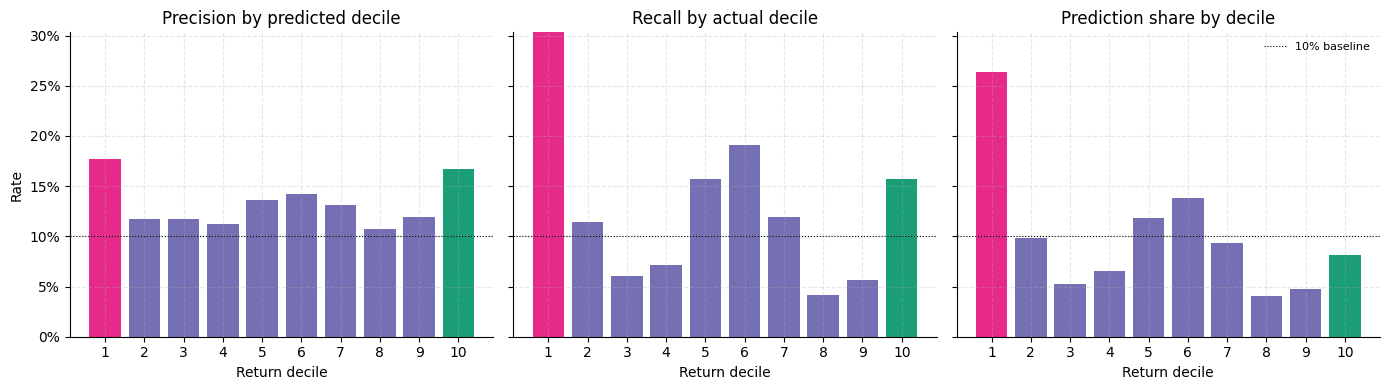

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
metrics_to_plot = [
    ("precision", "Precision by predicted decile"),
    ("recall", "Recall by actual decile"),
    ("pred_share", "Prediction share by decile"),
]

for ax, (col, title) in zip(axes, metrics_to_plot):
    colors = [PALETTE["secondary"]] * 10
    colors[0] = PALETTE["accent"]
    colors[-1] = PALETTE["primary"]
    ax.bar(decile_diag.index.astype(str), decile_diag[col], color=colors)
    ax.axhline(0.10, color="black", linewidth=0.8, linestyle=":", label="10% baseline")
    ax.set_title(title)
    ax.set_xlabel("Return decile")
    ax.set_ylim(0, max(0.30, decile_diag[col].max() * 1.15))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
axes[0].set_ylabel("Rate")
axes[-1].legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()


## 6. Monthly Selection Diagnostics — Not Canonical Performance

This section keeps the paper-style/monthly equal-weighted portfolio view for sanity checks only. It is useful for inspecting ranking direction, long/short candidate counts, and rough leg behavior, but it is **not** the performance engine because it depends on monthly `fwd_return_mt` availability and cannot model execution, missing bars, delistings, or daily short squeezes. Use Section 8 daily results for capital and viability decisions.


In [11]:
print('NOTE: monthly results are diagnostics only; Section 8 daily backtest is canonical performance.')
from portfolio import run_all_strategies, print_performance_table

results = run_all_strategies(
    featured, predictions,
    top_n=TOP_N,
    tc_bps=TC_BPS,
    carry_long_annual=CARRY_LONG_ANNUAL,
    carry_short_annual=CARRY_SHORT_ANNUAL,
    days=DAYS_PER_MONTH,
    long_only=LONG_ONLY,
)
print_performance_table(results)


NOTE: monthly results are diagnostics only; Section 8 daily backtest is canonical performance.
  MOM: ann.ret   15.6%  sharpe  0.66  comm  13.1bp/mo  fin  41.1bp/mo  months 424
  XGB: ann.ret   18.4%  sharpe  0.90  comm  26.5bp/mo  fin  41.1bp/mo  months 315
  RET: ann.ret   18.9%  sharpe  0.90  comm  25.8bp/mo  fin  41.1bp/mo  months 315
  SRP: ann.ret   17.6%  sharpe  0.98  comm  27.3bp/mo  fin  41.1bp/mo  months 315
  CVR: ann.ret   17.8%  sharpe  0.97  comm  27.2bp/mo  fin  41.1bp/mo  months 315

Strategy   Ann.Ret   Ann.Vol   Sharpe    Cum.Ret    MaxDD   t-stat  Months    Comm     Fin
------------------------------------------------------------------------------------------
MOM         15.6%    23.7%    0.658   8773.9%  -60.0%     3.91     424  13.1bp  41.1bp
XGB         18.4%    20.3%    0.903   6879.2%  -40.6%     4.62     315  26.5bp  41.1bp
RET         18.9%    20.9%    0.905   7758.8%  -41.3%     4.64     315  25.8bp  41.1bp
SRP         17.6%    18.0%    0.977   6380.1%  -39.

### 6a. Equity curves — five strategies


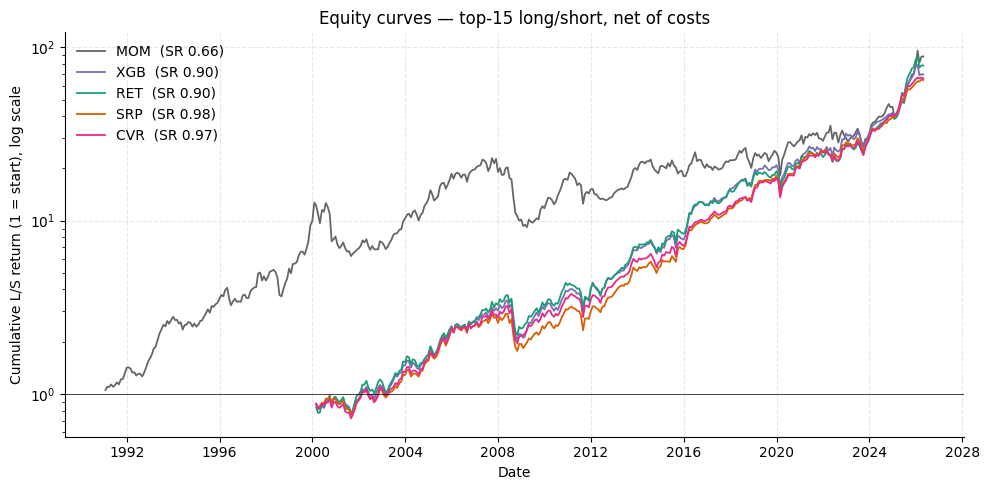

In [12]:
import numpy as np

fig, ax = plt.subplots()
colors = {
    'MOM': PALETTE['neutral'],
    'XGB': PALETTE['secondary'],
    'RET': PALETTE['primary'],
    'SRP': PALETTE['tertiary'],
    'CVR': PALETTE['accent'],
}
for name in ['MOM', 'XGB', 'RET', 'SRP', 'CVR']:
    port = results[name]['portfolio']
    if port.empty: continue
    cum = (1 + port['ls_ret']).cumprod()
    sr = results[name]['metrics']['sharpe']
    ax.plot(port['date_mt'], cum, color=colors[name], linewidth=1.3,
            label=f'{name}  (SR {sr:.2f})')
ax.set_yscale('log')
ax.axhline(1, color='black', linewidth=0.5)
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative L/S return (1 = start), log scale')
ax.set_title(f'Equity curves — top-{TOP_N} long/short, net of costs')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [13]:
selection_counts = []
for name in ["MOM", "XGB", "RET", "SRP", "CVR"]:
    port = results[name]["portfolio"]
    if port.empty:
        continue
    selection_counts.append({
        "strategy": name,
        "months": len(port),
        "avg_n_long": port["n_long"].mean(),
        "avg_n_short": port["n_short"].mean(),
        "min_n_long": port["n_long"].min(),
        "min_n_short": port["n_short"].min(),
    })
pd.DataFrame(selection_counts).set_index("strategy").round(2)


,months,avg_n_long,avg_n_short,min_n_long,min_n_short
strategy,,,,,
MOM,424,15.0,0.0,15,0
XGB,315,15.0,0.0,15,0
RET,315,15.0,0.0,15,0
SRP,315,15.0,0.0,15,0
CVR,315,15.0,0.0,15,0


## 8. Daily Backtest — Canonical Performance Reporter

This is the performance engine for the project. It ranks/selects using forecast columns only (`prob_*`, `ret_score`, `srp_score`, `cvr_score`, or momentum), then evaluates the selected book from daily prices. It does not require `fwd_return_mt` to decide whether a stock was tradable/selectable. If a top-ranked name has no executable daily close at the entry date, it fills down to the next ranked executable name.

- **1-day execution lag**: signals observed at month-end close T, execution at T+1 close.
- **Daily mark-to-market** on actual stock daily closes between rebalances.
- **Missing bars vs delistings**: temporary missing prices are stale-marked; after the asset final observed bar, forward-fill for up to 3 trading days, then mark to zero.
- **Commission**: charged on dollars traded at each rebalance day, based on actual turnover.
- **Financing**: accrued daily on overnight positions.
- **Starting capital**: $100,000.

Monthly stats remain useful for diagnostics, but the daily-frequency Sharpe, MaxDD, and annual return below are the honest performance numbers.


In [14]:
from daily_backtest import backtest_ew_strategy, print_summary, STARTING_CAPITAL

daily = pd.read_parquet(DAILY_PATH)
daily_results = {}
daily_summaries = {}

print("Daily backtest — EW strategies\n" + "-"*70)
for strat in ["MOM", "XGB", "RET", "SRP", "CVR"]:
    daily_df, summary = backtest_ew_strategy(
        featured, predictions, daily, strat,
        top_n=TOP_N,
        tc_bps=TC_BPS,
        carry_long_annual=CARRY_LONG_ANNUAL,
        carry_short_annual=CARRY_SHORT_ANNUAL,
        long_only=LONG_ONLY,
        verbose=False,
    )
    daily_results[f"EW_{strat}"] = daily_df
    daily_summaries[f"EW_{strat}"] = summary
    print_summary(f"EW_{strat}", summary)


Daily backtest — EW strategies
----------------------------------------------------------------------
  EW_MOM: final $       217,486 | ann.ret    2.2% | ann.vol   26.4% | sharpe  0.22 | MaxDD  -88.8% | days  8859
  EW_XGB: final $       241,452 | ann.ret    3.4% | ann.vol   24.5% | sharpe  0.26 | MaxDD  -68.0% | days  6572
  EW_RET: final $       223,578 | ann.ret    3.1% | ann.vol   25.4% | sharpe  0.25 | MaxDD  -68.0% | days  6572
  EW_SRP: final $       195,997 | ann.ret    2.6% | ann.vol   22.1% | sharpe  0.23 | MaxDD  -69.9% | days  6572
  EW_CVR: final $       112,956 | ann.ret    0.5% | ann.vol   23.2% | sharpe  0.14 | MaxDD  -69.6% | days  6572


### 8a. Daily equity curves


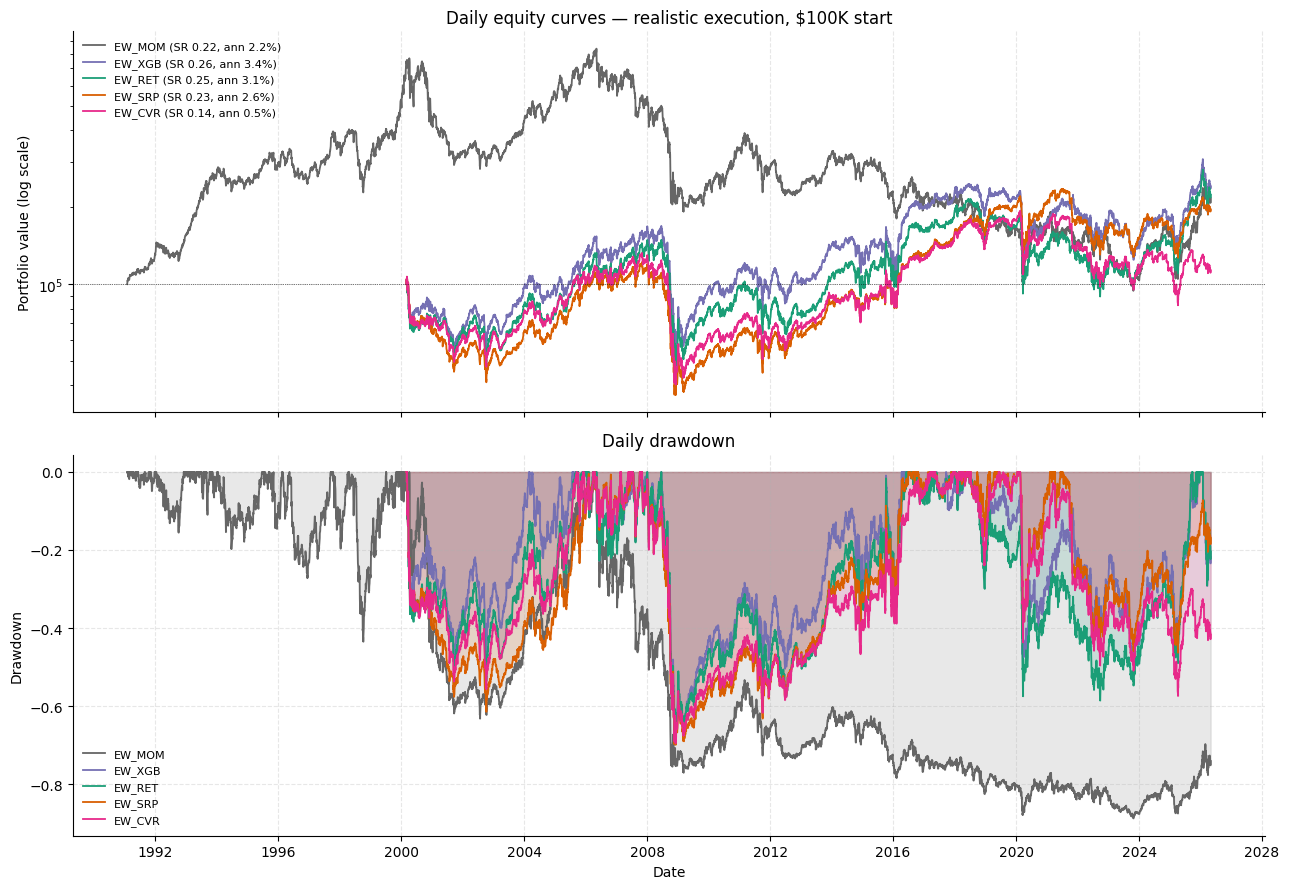

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

# Top: log-scale equity
colors = {
    'EW_MOM': PALETTE['neutral'],
    'EW_XGB': PALETTE['secondary'],
    'EW_RET': PALETTE['primary'],
    'EW_SRP': PALETTE['tertiary'],
    'EW_CVR': PALETTE['accent'],
}
for name, df in daily_results.items():
    if df.empty: continue
    s = daily_summaries.get(name, {})
    label = f'{name} (SR {s.get("sharpe_ratio", 0):.2f}, ann {s.get("annualized_return", 0):.1%})'
    color = colors.get(name, PALETTE['tertiary'] if 'OPT' in name else 'black')
    lw = 1.8 if 'OPT' in name else 1.3
    axes[0].plot(df['date'], df['equity'], label=label, color=color, linewidth=lw)
axes[0].set_yscale('log')
axes[0].axhline(STARTING_CAPITAL, color='black', linewidth=0.5, linestyle=':')
axes[0].set_ylabel('Portfolio value (log scale)')
axes[0].set_title('Daily equity curves — realistic execution, $100K start')
axes[0].legend(loc='upper left', fontsize=8)

# Bottom: drawdown
for name, df in daily_results.items():
    if df.empty: continue
    color = colors.get(name, PALETTE['tertiary'] if 'OPT' in name else 'black')
    lw = 1.8 if 'OPT' in name else 1.3
    axes[1].fill_between(df['date'], df['drawdown'], 0, color=color, alpha=0.15)
    axes[1].plot(df['date'], df['drawdown'], label=name, color=color, linewidth=lw)
axes[1].set_ylabel('Drawdown')
axes[1].set_xlabel('Date')
axes[1].set_title('Daily drawdown')
axes[1].legend(loc='lower left', fontsize=8)

plt.tight_layout()
plt.show()

### 8b. Realistic performance summary (daily-frequency)


In [16]:
rows = []
for name, s in daily_summaries.items():
    if not s: continue
    rows.append({
        'strategy':       name,
        'final_$':        s['final_equity'],
        'total_ret':      s['total_return'],
        'ann_ret':        s['annualized_return'],
        'ann_vol':        s['annualized_vol'],
        'sharpe':         s['sharpe_ratio'],
        'max_dd':         s['max_drawdown'],
        'win_rate_daily': s['win_rate'],
        'var_95_daily':   s['var_95_daily'],
        'avg_positions':  s['avg_positions'],
        'total_comm_$':   s['total_commission_$'],
        'total_fin_$':    s['total_financing_$'],
    })
import pandas as pd
df_summary = pd.DataFrame(rows).set_index('strategy')
df_summary.round(4)

,final_$,total_ret,ann_ret,ann_vol,sharpe,max_dd,win_rate_daily,var_95_daily,avg_positions,total_comm_$,total_fin_$
strategy,,,,,,,,,,,
EW_MOM,217485.7006,1.1749,0.0223,0.2637,0.2170,-0.8877,0.5406,-0.0256,15.0,176669.3443,359034.6582
EW_XGB,241451.9885,1.4145,0.0344,0.2450,0.2614,-0.6802,0.5399,-0.0236,15.0,122453.3195,126679.4019
EW_RET,223577.5920,1.2358,0.0313,0.2536,0.2495,-0.6799,0.5418,-0.0248,15.0,98086.6828,103574.9273
EW_SRP,195996.7491,0.9600,0.0261,0.2214,0.2284,-0.6990,0.5495,-0.0201,15.0,100272.0327,99890.8249
EW_CVR,112955.6483,0.1296,0.0047,0.2319,0.1373,-0.6957,0.5491,-0.0213,15.0,91318.5141,92468.9915


### 8c. Recent 10-Year Daily Equity Curves

This view rebases each daily equity curve to 1.0 at the start of the last 10 years available in the daily backtest output. It is often more useful than the full sample because the early years can dominate the log chart.


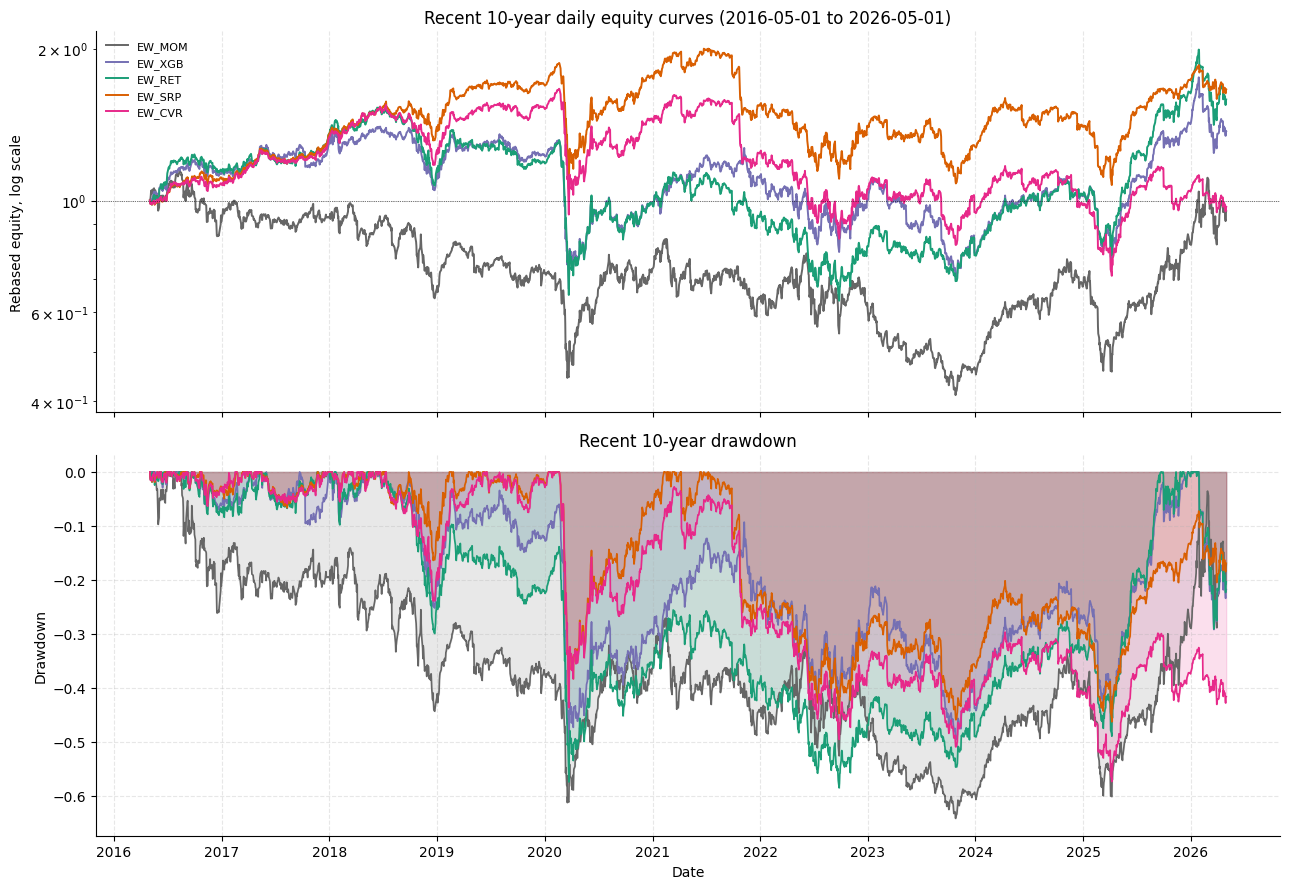

In [17]:
# Recent 10-year daily equity curves, rebased to 1.0.
all_daily_dates = pd.concat([
    df[["date"]] for df in daily_results.values() if not df.empty
], ignore_index=True)
recent_end = all_daily_dates["date"].max()
recent_start = recent_end - pd.DateOffset(years=10)

fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

for name, df in daily_results.items():
    if df.empty:
        continue
    sub = df[df["date"] >= recent_start].copy()
    if sub.empty:
        continue
    base_equity = sub["equity"].iloc[0]
    sub["equity_rebased"] = sub["equity"] / base_equity
    sub["peak_rebased"] = sub["equity_rebased"].cummax()
    sub["drawdown_rebased"] = sub["equity_rebased"] / sub["peak_rebased"] - 1

    color = colors.get(name, PALETTE["tertiary"] if "OPT" in name else "black")
    axes[0].plot(sub["date"], sub["equity_rebased"], label=name, color=color, linewidth=1.4)
    axes[1].fill_between(sub["date"], sub["drawdown_rebased"], 0, color=color, alpha=0.15)
    axes[1].plot(sub["date"], sub["drawdown_rebased"], color=color, linewidth=1.2)

axes[0].set_yscale("log")
axes[0].axhline(1, color="black", linewidth=0.5, linestyle=":")
axes[0].set_ylabel("Rebased equity, log scale")
axes[0].set_title(f"Recent 10-year daily equity curves ({recent_start.date()} to {recent_end.date()})")
axes[0].legend(loc="upper left", fontsize=8)
axes[1].set_ylabel("Drawdown")
axes[1].set_xlabel("Date")
axes[1].set_title("Recent 10-year drawdown")
plt.tight_layout()
plt.show()


### 8d. Recent 10-Year Daily Stats

Same daily return stream as Section 8b, filtered to the recent 10-year window and recomputed from daily returns.


In [18]:
# Recent 10-year daily statistics.
recent_rows = []
TRADING_DAYS_PER_YEAR = 252

for name, df in daily_results.items():
    if df.empty:
        continue
    sub = df[df["date"] >= recent_start].copy()
    if len(sub) < 2:
        continue

    eq0 = sub["equity"].iloc[0]
    eq1 = sub["equity"].iloc[-1]
    total_ret = eq1 / eq0 - 1
    n_days = len(sub)
    ann_ret = (eq1 / eq0) ** (TRADING_DAYS_PER_YEAR / n_days) - 1
    r = sub["daily_ret"]
    ann_vol = r.std() * np.sqrt(TRADING_DAYS_PER_YEAR)
    sharpe = (r.mean() * TRADING_DAYS_PER_YEAR) / ann_vol if ann_vol > 0 else np.nan
    peak = sub["equity"].cummax()
    max_dd = (sub["equity"] / peak - 1).min()

    recent_rows.append({
        "strategy": name,
        "start": sub["date"].iloc[0],
        "end": sub["date"].iloc[-1],
        "n_days": n_days,
        "total_ret": total_ret,
        "ann_ret": ann_ret,
        "ann_vol": ann_vol,
        "sharpe": sharpe,
        "max_dd": max_dd,
        "win_rate_daily": (r > 0).mean(),
        "var_95_daily": np.percentile(r, 5),
        "avg_positions": sub["n_positions"].mean(),
        "total_commission_$": sub["commission_$"].sum(),
        "total_financing_$": sub["financing_$"].sum(),
    })

recent_10y_stats = pd.DataFrame(recent_rows).set_index("strategy")
recent_10y_stats.round(4)


,start,end,n_days,total_ret,ann_ret,ann_vol,sharpe,max_dd,win_rate_daily,var_95_daily,avg_positions,total_commission_$,total_financing_$
strategy,,,,,,,,,,,,,
EW_MOM,2016-05-02,2026-05-01,2510,-0.0477,-0.0049,0.3021,0.1373,-0.6423,0.5410,-0.0318,15.0,30133.5970,57611.1057
EW_XGB,2016-05-02,2026-05-01,2510,0.3721,0.0323,0.2368,0.2487,-0.5231,0.5402,-0.0220,15.0,70055.1679,67257.9030
EW_RET,2016-05-02,2026-05-01,2510,0.5856,0.0474,0.2434,0.3097,-0.5858,0.5398,-0.0221,15.0,53948.0236,53415.8508
EW_SRP,2016-05-02,2026-05-01,2510,0.6613,0.0523,0.2065,0.3462,-0.4633,0.5482,-0.0172,15.0,63238.8783,59327.9414
EW_CVR,2016-05-02,2026-05-01,2510,-0.0284,-0.0029,0.2198,0.0931,-0.5740,0.5470,-0.0179,15.0,51149.5231,48343.8971


## 9. Paper-Style Country Tables

The paper reports country-level model quality, bimodality, portfolio performance, crash risk, and sample/universe statistics. This project currently has Canada only, so the table below is one row. If a future dataset includes a `country` column, the same pattern can be expanded into country-by-country groups.


In [19]:
from metrics import compute_bimodality, compute_crash_rate

country_name = "Canada"

# Model quality, full OOS cross-section.
model_row = {
    "country": country_name,
    "oos_obs": acc["n_obs"],
    "accuracy": acc["accuracy"],
    "precision_H": acc["precision_H"],
    "precision_L": acc["precision_L"],
    "recall_H": acc["recall_H"],
    "recall_L": acc["recall_L"],
    "pred_share_H": acc["pred_ratio_H"],
    "pred_share_L": acc["pred_ratio_L"],
}

# Paper bimodality metrics for naive XGB class predictions.
bm = compute_bimodality(preds_eval, pred_col="xgb_class", actual_col="LABEL_mt")
for key in ["HH", "HL", "LL", "LH", "BM"]:
    model_row[key] = bm.get(key, np.nan)

# Universe/sample statistics.
model_row.update({
    "daily_start": pd.to_datetime(daily["date"]).min(),
    "daily_end": pd.to_datetime(daily["date"]).max(),
    "n_assets_daily": daily["assetid"].nunique(),
    "n_assets_filtered": featured["assetid"].nunique(),
    "avg_monthly_universe": featured.groupby(featured["date_mt"].dt.to_period("M"))["assetid"].nunique().mean(),
})

country_model_stats = pd.DataFrame([model_row]).set_index("country")
country_model_stats.round(4)


,oos_obs,accuracy,precision_H,precision_L,recall_H,recall_L,pred_share_H,pred_share_L,HH,HL,LL,LH,BM,daily_start,daily_end,n_assets_daily,n_assets_filtered,avg_monthly_universe
country,,,,,,,,,,,,,,,,,,
Canada,97335,0.1434,0.1667,0.177,0.1572,0.4876,0.0816,0.2637,0.0717,0.0585,0.0865,0.0387,-0.0305,1990-01-02,2026-05-01,14156,2903,397.4679


In [20]:
# Daily canonical performance table, one row per strategy.
perf_rows = []
for name, s in daily_summaries.items():
    if not s:
        continue
    strat = name.replace("EW_", "")
    monthly_port = results.get(strat, {}).get("portfolio", pd.DataFrame())
    perf_rows.append({
        "country": country_name,
        "strategy": strat,
        "daily_ann_ret": s["annualized_return"],
        "daily_ann_vol": s["annualized_vol"],
        "daily_sharpe": s["sharpe_ratio"],
        "daily_max_dd": s["max_drawdown"],
        "daily_total_ret": s["total_return"],
        "daily_var_95": s["var_95_daily"],
        "n_rebalances": s["n_rebalances"],
        "avg_positions": s["avg_positions"],
        "monthly_diag_mean_ann": monthly_port["ls_ret"].mean() * 12 if not monthly_port.empty else np.nan,
        "monthly_diag_crash_rate": compute_crash_rate(monthly_port) if not monthly_port.empty else np.nan,
    })

country_strategy_stats = pd.DataFrame(perf_rows).set_index(["country", "strategy"])
country_strategy_stats.round(4)


daily_ann_ret  daily_ann_vol  daily_sharpe  daily_max_dd  \
country strategy                                                             
Canada  MOM              0.0223         0.2637        0.2170       -0.8877   
        XGB              0.0344         0.2450        0.2614       -0.6802   
        RET              0.0313         0.2536        0.2495       -0.6799   
        SRP              0.0261         0.2214        0.2284       -0.6990   
        CVR              0.0047         0.2319        0.1373       -0.6957   

                  daily_total_ret  daily_var_95  n_rebalances  avg_positions  \
country strategy                                                               
Canada  MOM                1.1749       -0.0256           424           15.0   
        XGB                1.4145       -0.0236           315           15.0   
        RET                1.2358       -0.0248           315           15.0   
        SRP                0.9600       -0.0201           315           15.0   
        CVR                0.1296       -0.0213           315           15.0   

                  monthly_diag_mean_ann  monthly_diag_crash_rate  
country strategy                                                  
Canada  MOM                      0.1561                   0.2662  
        XGB                      0.1836                   0.1086  
        RET                      0.1893                   0.1186  
        SRP                      0.1763                   0.1053  
        CVR                      0.1778                   0.1053

In [21]:
# Long/short leg diagnostics from the monthly diagnostic layer.
# Useful for the short-leg puzzle, but not a substitute for daily P&L.
leg_rows = []
for strat in ["MOM", "XGB", "RET", "SRP", "CVR"]:
    port = results[strat]["portfolio"]
    if port.empty:
        continue
    leg_rows.append({
        "strategy": strat,
        "long_ann_mean": port["long_ret"].mean() * 12,
        "short_realized_ann_mean": port["short_ret"].mean() * 12,
        "gross_ls_ann_mean": port["ls_ret_gross"].mean() * 12,
        "worst_ls_month": port["ls_ret"].min(),
        "worst_short_realized_month": port["short_ret"].max(),
        "best_short_realized_month": port["short_ret"].min(),
    })

leg_diagnostics = pd.DataFrame(leg_rows).set_index("strategy")
leg_diagnostics.round(4)


,long_ann_mean,short_realized_ann_mean,gross_ls_ann_mean,worst_ls_month,worst_short_realized_month,best_short_realized_month
strategy,,,,,,
MOM,0.2211,0.0,0.2211,-0.3069,0.0,0.0
XGB,0.2647,0.0,0.2647,-0.2262,0.0,0.0
RET,0.2696,0.0,0.2696,-0.2163,0.0,0.0
SRP,0.2583,0.0,0.2583,-0.1924,0.0,0.0
CVR,0.2598,0.0,0.2598,-0.2131,0.0,0.0


## 10. Monthly-vs-Daily Bridge Diagnostic

This reconciles the gap directly for the focus strategy. It ranks by forecast, applies the daily fill-down rule, then compares monthly `fwd_return_mt` against daily execution-window returns for the same selected names.


In [22]:
from bridge_diag import build_monthly_daily_bridge, print_bridge_report

bridge_pos, bridge_month = build_monthly_daily_bridge(
    featured, predictions, daily,
    strategy="RET",
    top_n=TOP_N,
    execution_lag_days=1,
    long_only=LONG_ONLY,
)
print_bridge_report(bridge_pos, bridge_month, long_only=LONG_ONLY)


Bridge coverage
------------------------------------------------------------------------
Positions: 4,710
Months:    314
Missing monthly leg returns: 193
Missing daily leg returns:   31
Source rows before rebalance date: 0

Monthly aggregate comparison
------------------------------------------------------------------------
       monthly_ls_ret  daily_ls_ret     ls_diff
count      314.000000    314.000000  314.000000
mean         0.023008      0.016013   -0.006995
std          0.057303      0.073096    0.034622
min         -0.156335     -0.315140   -0.213709
1%          -0.130111     -0.244381   -0.152086
5%          -0.065125     -0.087481   -0.062608
50%          0.022770      0.017400   -0.002839
95%          0.116525      0.121851    0.031683
99%          0.166422      0.182392    0.055164
max          0.179959      0.299138    0.182332

Correlation monthly vs daily: 0.887

Worst divergence months by |daily - monthly|
---------------------------------------------------------------

In [23]:
# Table form for notebook inspection.
bridge_month.sort_values("ls_diff", key=lambda s: s.abs(), ascending=False).head(20).round(4)


,date_mt,L_monthly_ret,L_daily_ret,L_n,L_missing_monthly,L_missing_daily,S_monthly_ret,S_daily_ret,S_n,S_missing_monthly,S_missing_daily,monthly_ls_ret,daily_ls_ret,ls_diff
104,2008-10-31,-0.0323,-0.2460,15,6,0,NaN,NaN,NaN,NaN,NaN,-0.0323,-0.2460,-0.2137
105,2008-11-28,0.1168,0.2991,15,1,0,NaN,NaN,NaN,NaN,NaN,0.1168,0.2991,0.1823
103,2008-09-30,-0.0999,-0.2741,15,6,0,NaN,NaN,NaN,NaN,NaN,-0.0999,-0.2741,-0.1742
240,2020-02-28,-0.1533,-0.3151,15,5,1,NaN,NaN,NaN,NaN,NaN,-0.1533,-0.3151,-0.1618
106,2008-12-31,0.0025,-0.1556,15,5,0,NaN,NaN,NaN,NaN,NaN,0.0025,-0.1556,-0.1581
267,2022-05-31,-0.0581,-0.1698,15,6,0,NaN,NaN,NaN,NaN,NaN,-0.0581,-0.1698,-0.1117
30,2002-08-30,-0.0303,-0.1392,15,8,1,NaN,NaN,NaN,NaN,NaN,-0.0303,-0.1392,-0.1089
9,2000-11-30,0.1030,-0.0020,15,1,0,NaN,NaN,NaN,NaN,NaN,0.1030,-0.0020,-0.1051
107,2009-01-30,0.0192,-0.0811,15,2,0,NaN,NaN,NaN,NaN,NaN,0.0192,-0.0811,-0.1004
138,2011-08-31,-0.1544,-0.2444,15,4,0,NaN,NaN,NaN,NaN,NaN,-0.1544,-0.2444,-0.0900


In [24]:
bridge_pos.dropna(subset=["diff"]).sort_values(
    "diff", key=lambda s: s.abs(), ascending=False
).head(30)[[
    "date_mt", "symbol", "direction", "weight", "entry_date", "exit_date",
    "source_date_mt", "monthly_stock_ret", "daily_stock_ret", "diff", "entry_px", "exit_px"
]].round(4)


,date_mt,symbol,direction,weight,entry_date,exit_date,source_date_mt,monthly_stock_ret,daily_stock_ret,diff,entry_px,exit_px
1587,2008-11-28,IMN,L,0.0667,2008-12-01,2009-01-02,2008-11-28,0.0177,0.5104,0.0329,15.0893,22.7915
138,2000-11-30,BB,L,0.0667,2000-12-01,2001-01-02,2000-11-30,0.2172,-0.2476,-0.0310,19.2500,14.4833
1575,2008-11-28,TECK.B,L,0.0667,2008-12-01,2009-01-02,2008-11-28,0.0033,0.4153,0.0275,3.7146,5.2574
52,2000-05-31,CIC,L,0.0667,2000-06-01,2000-07-04,2000-05-31,1.1243,0.7258,-0.0266,31.0000,53.5000
1576,2008-11-28,FM,L,0.0667,2008-12-01,2009-01-02,2008-11-28,-0.0377,0.3209,0.0239,2.9503,3.8970
1588,2008-11-28,GNA,L,0.0667,2008-12-01,2009-01-02,2008-11-28,0.2450,0.5878,0.0228,5.0433,8.0076
3218,2017-12-29,CMED,L,0.0667,2018-01-02,2018-02-01,2017-12-29,0.5632,0.2422,-0.0214,24.1500,30.0000
17,2000-03-31,CIC,L,0.0667,2000-04-03,2000-05-01,2000-03-31,-0.4831,-0.1730,0.0207,48.9750,40.5000
2,2000-02-29,CIC,L,0.0667,2000-03-01,2000-04-03,2000-02-29,-0.1829,-0.4912,-0.0205,96.2500,48.9750
211,2001-04-30,GIL,L,0.0667,2001-05-01,2001-06-01,2001-04-30,-0.1289,0.1782,0.0205,2.1972,2.5888
